# Proyecto IA 1 - Parcial 3
**Integrantes:** Santiago Ardila, Santiago Flórez, María Lucía Rodríguez

**Códigos:** 2230086, 2230096, 2231853
![ckd](https://drive.google.com/uc?export=view&id=15_Cijtvt6Jp3O3XjtnJN4MTBmDU3Ijps)

# Subida de datos

In [1]:
# Importar librerias y cargar el drive para agregar el dataset
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import *

path_ai = "/IA/Proyecto"
path = "/content/drive/My Drive/" + path_ai
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1sCHJYLzYRzxjAg4ej7k-oy-pY65IHBhM/Proyecto


In [2]:
# Cargar el dataset
dataset = pd.read_csv("/content/drive/MyDrive/IA/Proyecto/ckd_stages_dataset.csv")

In [3]:
# Renombrar las variables para que sean más legible
col={'age': 'age',
     'bp': 'blood_pressure',
     'sg': 'specific_gravity',
     'al': 'albumin',
     'su': 'sugar',
     'rbc': 'red_blood_cells',
     'pc': 'pus_cell',
     'pcc': 'pus_cell_clumps',
     'ba': 'bacteria',
     'bgr': 'blood_glucose_random',
     'bu': 'blood_urea',
     'sc': 'serum_creatinine',
     'sod': 'sodium',
     'pot': 'potassium',
     'hemo': 'hemoglobin',
     'pcv': 'packed_cell_volume',
     'wc': 'white_blood_cell_count',
     'rc': 'red_blood_cell_count',
     'htn': 'hypertension',
     'dm': 'diabetes_mellitus',
     'cad': 'coronary_artery_disease',
     'appet': 'appetite',
     'pe': 'pedal_edema',
     'ane': 'anemia',
     'classification': 'class'}
dataset.rename(columns=col, inplace=True)

In [4]:
# Convertir columnas númericas mal tipadas (guardadas como strings)
dataset['packed_cell_volume'] = pd.to_numeric(dataset['packed_cell_volume'].str.strip().replace('?', None), errors='coerce')
dataset['white_blood_cell_count'] = pd.to_numeric(dataset['white_blood_cell_count'].str.strip().replace('?', None), errors='coerce')
dataset['red_blood_cell_count'] = pd.to_numeric(dataset['red_blood_cell_count'].str.strip().replace('?', None), errors='coerce')

# Limpiar espacios y tabulaciones en variables categóricas y en class
dataset['diabetes_mellitus'] = dataset['diabetes_mellitus'].str.strip()
dataset['coronary_artery_disease'] = dataset['coronary_artery_disease'].str.strip()
dataset['class'] = dataset['class'].str.strip()

# Corregir la concordancia de los datos
dataset.loc[dataset['class'] == 'notckd', 'ckd_stage'] = 0
dataset.loc[dataset['ckd_stage'] == 0, 'class'] = 'notckd'

# Imputación de datos

In [5]:
# Mapeamos los valores de las variables categóricas para facilitar los modelos
dataset['hypertension'] = dataset['hypertension'].map({'yes': 1, 'no': 0})
dataset['pedal_edema'] = dataset['pedal_edema'].map({'yes': 1, 'no': 0})
dataset['diabetes_mellitus'] = dataset['diabetes_mellitus'].map({'yes': 1, 'no': 0})
dataset['red_blood_cells'] = dataset['red_blood_cells'].map({'abnormal': 1, 'normal': 0})
dataset['anemia'] = dataset['anemia'].map({'yes': 1, 'no': 0})
dataset['appetite'] = dataset['appetite'].map({'poor': 1, 'good': 0})
dataset['pus_cell'] = dataset['pus_cell'].map({'abnormal': 1, 'normal': 0})
dataset['pus_cell_clumps'] = dataset['pus_cell_clumps'].map({'present': 1, 'notpresent': 0})
dataset['bacteria'] = dataset['bacteria'].map({'present': 1, 'notpresent': 0})
dataset['coronary_artery_disease'] = dataset['coronary_artery_disease'].map({'yes': 1, 'no': 0})

In [6]:
from sklearn.impute import KNNImputer

# Variables númericas - KNN Imputer
imputer = KNNImputer(n_neighbors=5)

cols_numericas = dataset.select_dtypes(include='number').columns

dataset[cols_numericas] = imputer.fit_transform(dataset[cols_numericas])

# Definición de datos

In [7]:
X = dataset.drop(columns=['ckd_stage', 'id', 'class'])
y = dataset['ckd_stage']

# Normalización de datos

In [8]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# Normalizacion
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Convertimos a one-hot encoding
y_cat = to_categorical(y, num_classes=6)

print(f"Shape X: {X_scaled_df.shape}")
print(f"Shape y: {y_cat.shape}")

Shape X: (400, 25)
Shape y: (400, 6)


La normalización es obligatoria, ya que Keras usa un ajuste de pesos mediante gradiente descente y si las variables tienen escalas muy distintas el entrenamiento se vuelve inestable.

# Deep Learning

## Pruebas con funciones de activación

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import f1_score

funciones_activacion = ['relu', 'tanh']
resultados_activacion = {}

# Usamos smote para los datos de entrenamiento
smote = SMOTE(random_state=42)

# Split unico 90/10
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE solo sobre entrenamiento
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
y_train_bal_cat = to_categorical(y_train_bal, num_classes=6)

for activacion in funciones_activacion:
  print(f"\n{'='*50}")
  print(f"# Función de activación: {activacion.upper()}")
  print(f"{'='*50}")

  y_real_total = []
  y_pred_total = []

    # Modelo
  modelo = Sequential([
      Input(shape=(X_scaled_df.shape[1],)),
      Dense(64, activation=activacion),
      # Agregamos un dropout, este apaga aleatoriamente un porcentaje de las neuronas de la capa anterior,
      # obligando a la red a no depender demasiado de ninguna neurona especifica y aprender representaciones mas generales
      Dropout(0.3),
      Dense(32, activation=activacion),
      Dropout(0.3),
      Dense(16, activation=activacion),
      Dropout(0.3),
      Dense(6, activation='softmax')
  ])

  modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  modelo.fit(X_train_bal, y_train_bal_cat, epochs=200, verbose=0);

  predictions = np.argmax(modelo.predict(X_test), axis=1)

  y_real_total.extend(y_test)
  y_pred_total.extend(predictions)

  print(classification_report(y_real_total, y_pred_total, target_names=[f'Etapa {i}' for i in range(6)]))

  f1 = f1_score(y_real_total, y_pred_total, average='macro')
  resultados_activacion[activacion] = round(f1, 4)
  print(f"F1 macro: {f1:.4f}")


# Función de activación: RELU
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
              precision    recall  f1-score   support

     Etapa 0       0.89      1.00      0.94        33
     Etapa 1       0.75      0.75      0.75         4
     Etapa 2       1.00      0.25      0.40         4
     Etapa 3       0.71      0.56      0.62         9
     Etapa 4       0.54      0.58      0.56        12
     Etapa 5       0.61      0.61      0.61        18

    accuracy                           0.75        80
   macro avg       0.75      0.62      0.65        80
weighted avg       0.75      0.75      0.74        80

F1 macro: 0.6482

# Función de activación: TANH
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
              precision    recall  f1-score   support

     Etapa 0       0.94      1.00      0.97        33
     Etapa 1       1.00      0.75      0.86         4
     Etapa 2       0.43      0.75      0.55         4
     Etapa 3       0.86      0.67      0.75         9
     Etapa 4       0.75      0.

In [33]:
from sklearn.ensemble import RandomForestClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir modelo con hiperparámetros optimizados
rf_optimizado = RandomForestClassifier(
    max_depth=20,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

# Acumular predicciones con StratifiedKFold + SMOTE
smote = SMOTE(random_state=42)
y_real_total = []
y_pred_total = []

for train_idx, test_idx in skf.split(X_scaled_df, y):
    X_train, X_test = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    rf_optimizado.fit(X_train_bal, y_train_bal)
    predictions = rf_optimizado.predict(X_test)

    y_real_total.extend(y_test)
    y_pred_total.extend(predictions)

print(classification_report(y_real_total, y_pred_total,
                            target_names=[f'Etapa {i}' for i in range(6)]))

              precision    recall  f1-score   support

     Etapa 0       0.98      0.99      0.99       168
     Etapa 1       0.80      0.84      0.82        19
     Etapa 2       0.89      0.80      0.84        20
     Etapa 3       0.81      0.93      0.87        45
     Etapa 4       0.93      0.91      0.92        58
     Etapa 5       0.94      0.88      0.91        90

    accuracy                           0.93       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.93      0.93      0.93       400



## Prueba de arquitecturas

In [35]:
# Split unico 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE solo sobre entrenamiento
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
y_train_bal_cat = to_categorical(y_train_bal, num_classes=6)

arquitecturas = {
    'Pequeña (32-16)' : [32, 16],
    'Mediana (64-32-16)' : [64, 32, 16],
    'Grande (128-64-32-16)': [128, 64, 32, 16]
}

resultados_arquitecturas = {}

for nombre_arq, capas in arquitecturas.items():
  print(f"\n{'='*50}")
  print(f"# Arquitectura: {nombre_arq}")
  print(f"{'='*50}")

  y_real_total = []
  y_pred_total = []

  # Modelo según arquitectura
  modelo = Sequential()
  Input(shape=(X_scaled_df.shape[1],))
  modelo.add(Dense(capas[0], activation='tanh'))
  modelo.add(Dropout(0.3))

  for neuronas in capas[1:]:
    modelo.add(Dense(neuronas, activation='tanh'))
    modelo.add(Dropout(0.3))

  modelo.add(Dense(6, activation='softmax'))

  modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  modelo.fit(X_train_bal, y_train_bal_cat, epochs=200, verbose=0)

  predictions = np.argmax(modelo.predict(X_test), axis=1)

  y_real_total.extend(y_test)
  y_pred_total.extend(predictions)

  f1 = f1_score(y_real_total, y_pred_total, average='macro')
  resultados_arquitecturas[nombre_arq] = round(f1, 4)
  print(f"F1 macro: {f1:.4f}")

# Tabla comparativa de arquitecturas
print("\nResumen arquitecturas:")
for arq, f1 in resultados_arquitecturas.items():
    print(f"  {arq}: {f1}")


# Arquitectura: Pequeña (32-16)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
F1 macro: 0.7414

# Arquitectura: Mediana (64-32-16)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
F1 macro: 0.7279

# Arquitectura: Grande (128-64-32-16)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
F1 macro: 0.7217

Resumen arquitecturas:
  Pequeña (32-16): 0.7414
  Mediana (64-32-16): 0.7279
  Grande (128-64-32-16): 0.7217


# No supervisado

## KMeans

In [36]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

km = KMeans(n_clusters=6, random_state=42, n_init=4)
clusters_km = km.fit_predict(X_scaled_df)

silhouette_km = silhouette_score(X_scaled_df, clusters_km)
print(f"KMeans — Silhouette Score: {silhouette_km:.4f}")

KMeans — Silhouette Score: 0.2071


## Agglomerative Clustering

In [37]:
agg = AgglomerativeClustering(n_clusters=6)
clusters_agg = agg.fit_predict(X_scaled_df)

silhouette_agg = silhouette_score(X_scaled_df, clusters_agg)
print(f"Agglomerative — Silhouette Score: {silhouette_agg:.4f}")

Agglomerative — Silhouette Score: 0.2158


## DBSCAN

In [38]:
# Buscar los mejores parámetros para DBSCAN
from itertools import product

mejores_params = None
mejor_silhouette = -1

for eps, min_samples in product([2.0, 2.5, 3.0, 3.5, 4.0], [3, 4, 5]):
  dbscan_test = DBSCAN(eps=eps, min_samples=min_samples)
  labels = dbscan_test.fit_predict(X_scaled_df)

  n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
  n_outliers = (labels == -1).sum()

  # Solo evaluar si encuentra entre 2 y 8 clusters y menos del 30% outliers
  if 2 <= n_clusters <= 8 and n_outliers < len(X_scaled_df) * 0.3:
    mask = labels != -1
    score = silhouette_score(X_scaled_df[mask], labels[mask])
    if score > mejor_silhouette:
      mejor_silhouette = score
      mejores_params = (eps, min_samples)
      mejores_labels = labels

print(f"Mejores parámetros: eps={mejores_params[0]}, min_samples={mejores_params[1]}")
print(f"Mejor Silhouette: {mejor_silhouette:.4f}")
print(f"Clusters encontrados: {len(set(mejores_labels)) - (1 if -1 in mejores_labels else 0)}")
print(f"Outliers: {(mejores_labels == -1).sum()}")

# Actualizar clusters_dbscan con los mejores parámetros
clusters_dbscan = mejores_labels

Mejores parámetros: eps=4.0, min_samples=5
Mejor Silhouette: 0.2871
Clusters encontrados: 2
Outliers: 99


El valor de 99 outliers implica una detección de aproximadamente 1 de cada 4 pacientes como un paciente atípico, esto puede darse a presentaciones inusuales, que no encajan en ninguna categoría estándar, de los datos de los pacientes.

Es destacable el hecho de que DBSCAN tenga el mejor Silhouette Score, esto puede sugerir que los clusters encuentran de forma libre una mejor manera de definirse que aquellos que están forzados a cierto número de grupos.

In [39]:
# Tabla comparativa
print("Resumen Silhouette Scores:")
print(f"KMeans : {silhouette_km:.4f}")
print(f"Agglomerative : {silhouette_agg:.4f}")
print(f"DBSCAN : {mejor_silhouette:.4f}")

Resumen Silhouette Scores:
KMeans : 0.2071
Agglomerative : 0.2158
DBSCAN : 0.2871


Valores obtenidos en KMeans y Agglomerative son esperables ya que las etapas del CKD no son grupos separables en el espacio sino más bien una progresión continua de la enfermedad, por lo que los límites entre las etapas son naturalmente difusos.

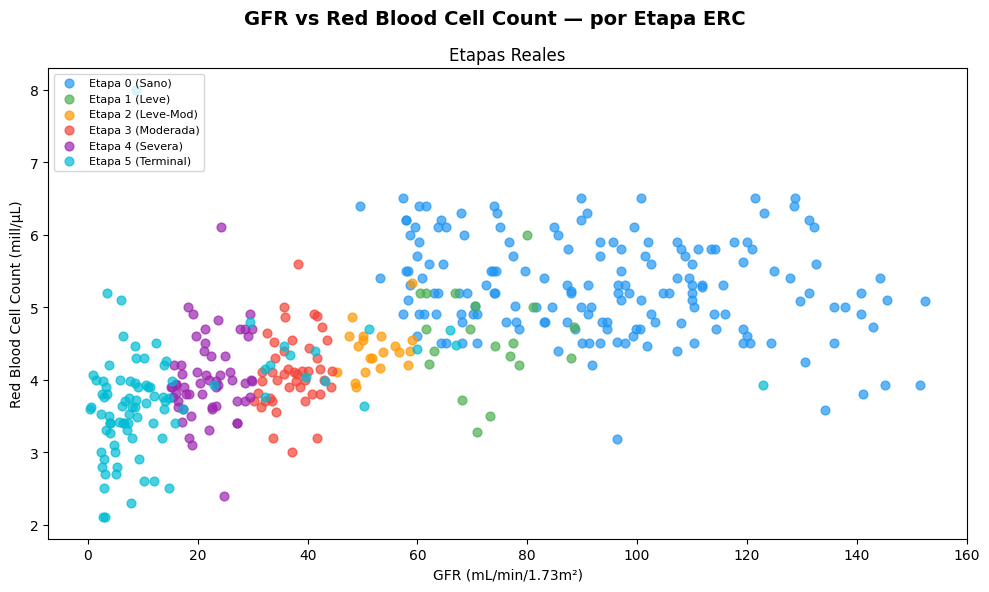

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('GFR vs Red Blood Cell Count — por Etapa ERC',
             fontsize=14, fontweight='bold')

colores_etapa = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']
etiquetas = ['Etapa 0 (Sano)', 'Etapa 1 (Leve)', 'Etapa 2 (Leve-Mod)',
             'Etapa 3 (Moderada)', 'Etapa 4 (Severa)', 'Etapa 5 (Terminal)']

# Filtrar nulos
mask_valid = dataset[['gfr', 'red_blood_cell_count']].notna().all(axis=1)
gfr_vals = dataset.loc[mask_valid, 'gfr']
rbc_vals  = dataset.loc[mask_valid, 'red_blood_cell_count']
y_valid   = y[mask_valid]

# --- Gráfica 1 — Etapas reales ---
for etapa in range(6):
    mask = y_valid == etapa
    axes.scatter(gfr_vals[mask], rbc_vals[mask],
                   c=colores_etapa[etapa], label=etiquetas[etapa],
                   alpha=0.7, s=40)
axes.set_title('Etapas Reales')
axes.set_xlabel('GFR (mL/min/1.73m²)')
axes.set_ylabel('Red Blood Cell Count (mill/µL)')
axes.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# Reducción dimensional

## PCA

In [41]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

print(f"Varianza explicada por componente : {pca.explained_variance_ratio_.round(4)}")
print(f"Varianza total explicada : {pca.explained_variance_ratio_.sum():.4f}")

Varianza explicada por componente : [0.3296 0.0737]
Varianza total explicada : 0.4033


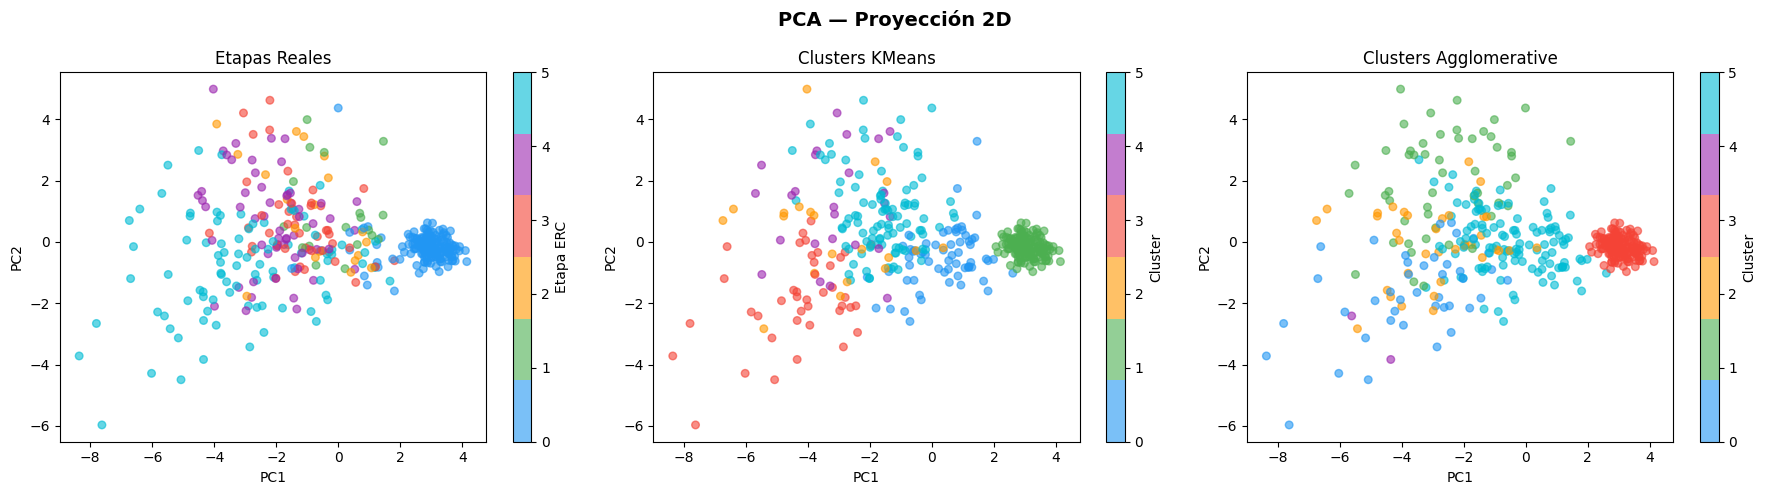

In [42]:
from matplotlib.colors import ListedColormap

colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']
cmap_custom = ListedColormap(colores)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PCA — Proyección 2D', fontsize=14, fontweight='bold')

# Coloreado por etapas reales
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=y, cmap=cmap_custom, alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[0], label='Etapa ERC')
axes[0].set_title('Etapas Reales')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Coloreado por clusters KMeans
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=clusters_km, cmap=cmap_custom, alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_title('Clusters KMeans')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Coloreado por clusters Agglomerative
scatter = axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=clusters_agg, cmap=cmap_custom, alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[2], label='Cluster')
axes[2].set_title('Clusters Agglomerative')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

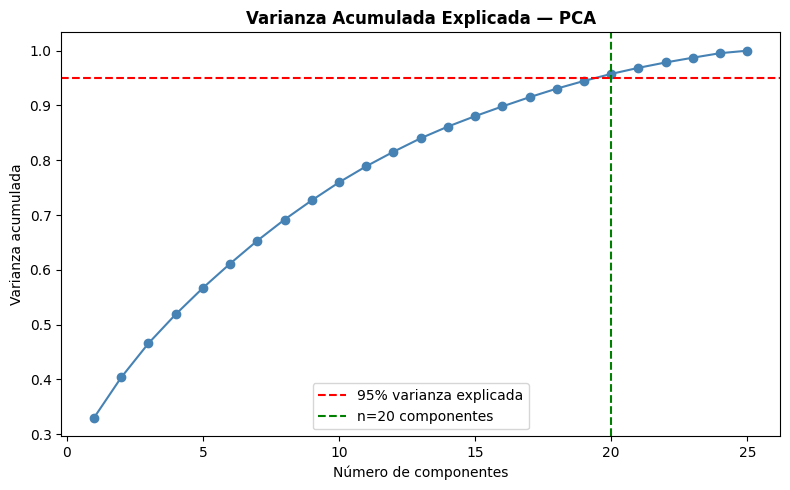

Componentes necesarios para explicar el 95% de la varianza: 20


In [43]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
        marker='o', color='steelblue')
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5,
           label='95% varianza explicada')
ax.axvline(x=np.argmax(varianza_acumulada >= 0.95) + 1,
           color='green', linestyle='--', linewidth=1.5,
           label=f'n={np.argmax(varianza_acumulada >= 0.95) + 1} componentes')
ax.set_title('Varianza Acumulada Explicada — PCA', fontweight='bold')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Componentes necesarios para explicar el 95% de la varianza: {np.argmax(varianza_acumulada >= 0.95) + 1}")

PCA - Etapas Reales: Se ve una separación parcial el grupo morado (Etapa 0, sanos) se concentra claramente a la derecha, separado del resto. Las etapas intermedias 2, 3 y 4 se mezclan bastante en el centro, lo cual es coherente con la progresión continua de la enfermedad. La varianza total explicada de solo 40% justifica por qué no hay separación perfecta, PCA está perdiendo el 60% de la información al reducir a 2 dimensiones, necesitando 20 componentes para el 95%.

PCA - KMeans vs Agglomerative: Ambos capturan el grupo morado de la derecha (Etapa 0) pero distribuyen diferente las etapas intermedias. Ninguno logra separación clara, consistente con el Silhouette Score bajo.

## t-SNE

In [44]:
# t-SNE a 2 componentes
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

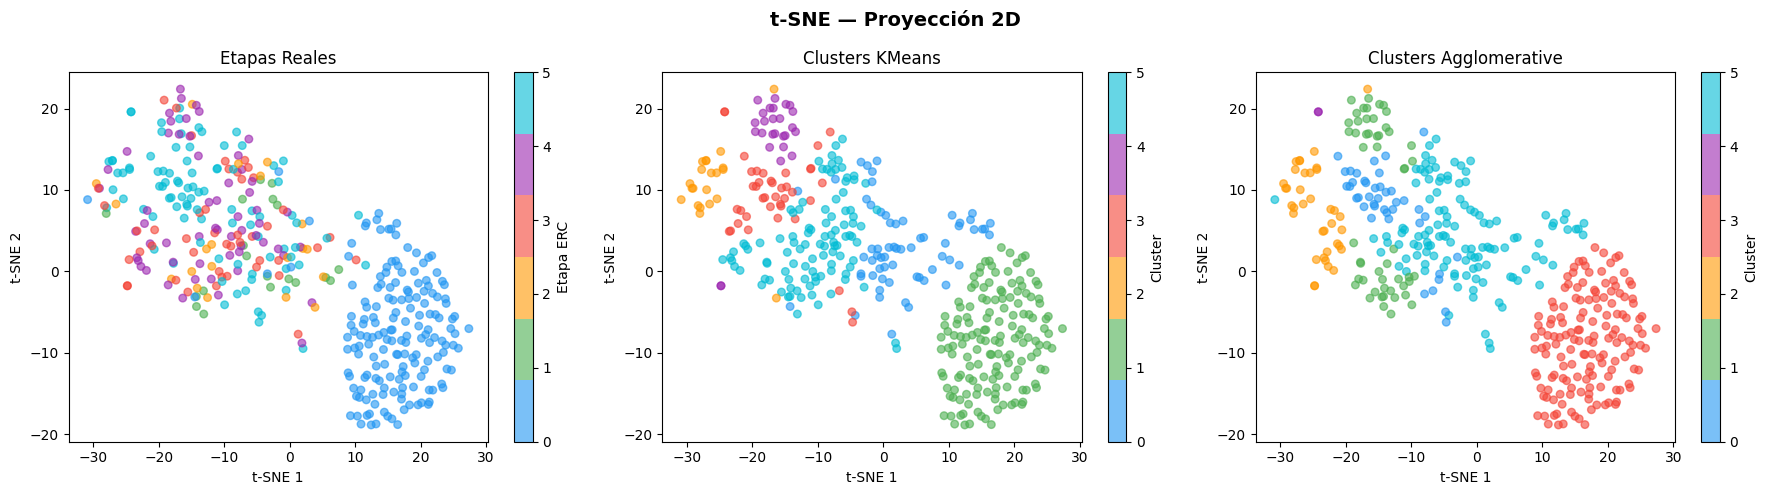

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('t-SNE — Proyección 2D', fontsize=14, fontweight='bold')

# Coloreado por etapas reales
scatter = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=y, cmap=cmap_custom, alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[0], label='Etapa ERC')
axes[0].set_title('Etapas Reales')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Coloreado por clusters KMeans
scatter = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=clusters_km, cmap=cmap_custom, alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_title('Clusters KMeans')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

# Coloreado por clusters Agglomerative
scatter = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=clusters_agg, cmap=cmap_custom, alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[2], label='Cluster')
axes[2].set_title('Clusters Agglomerative')
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

t-SNE - Etapas Reales: t-SNE muestra una estructura mucho más clara que PCA. Se ven dos regiones principales: la zona inferior con Etapa 0 muy concentrada, y la zona superior izquierda con las etapas avanzadas 4 y 5. Las etapas intermedias siguen mezcladas pero hay una tendencia gradual visible.

t-SNE - KMeans vs Agglomerative: KMeans captura mejor la estructura que Agglomerative en t-SNE — los clusters de KMeans se alinean más con las regiones naturales que muestra la proyección de etapas reales. Agglomerative tiende a crear clusters más compactos geométricamente pero menos coherentes clínicamente.

## Uso de PCA y t-SNE sobre mejor modelo de aprendizaje supervisado

In [46]:
# Convertir proyecciones a DataFrame
X_pca_2d = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_tsne_2d = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])

# PCA con 20 componentes
pca_20 = PCA(n_components=20, random_state=42)
X_pca_20 = pca_20.fit_transform(X_scaled)

espacios = {
    'PCA 2 componentes'  : X_pca_2d,
    'PCA 20 componentes' : pd.DataFrame(X_pca_20,
                           columns=[f'PC{i+1}' for i in range(20)]),
    't-SNE 2 componentes': X_tsne_2d
}

resultados_reduccion = {}

for nombre, X_reducido in espacios.items():
    print(f"\n{'='*50}")
    print(f"# {nombre}")
    print(f"{'='*50}")

    # Split
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_reducido, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_r_bal, y_train_r_bal = smote.fit_resample(X_train_r, y_train_r)

    # Random Forest optimizado
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=2,
        random_state=42
    )

    rf.fit(X_train_r_bal, y_train_r_bal)
    predictions = rf.predict(X_test_r)

    print(classification_report(y_test_r, predictions,
                                target_names=[f'Etapa {i}' for i in range(6)]))

    f1 = f1_score(y_test_r, predictions, average='macro')
    resultados_reduccion[nombre] = round(f1, 4)
    print(f"F1 macro: {f1:.4f}")

# Comparación final
print(f"\n{'='*50}")
print("Comparación Final — F1 macro RF:")
print(f"{'='*50}")
print(f"  Variables originales    : 0.89")
for nombre, f1 in resultados_reduccion.items():
    diferencia = f1 - 0.89
    signo = '+' if diferencia > 0 else ''
    print(f"  {nombre:30s}: {f1:.4f} ({signo}{diferencia:.4f})")


# PCA 2 componentes
              precision    recall  f1-score   support

     Etapa 0       0.97      0.94      0.95        33
     Etapa 1       0.17      0.25      0.20         4
     Etapa 2       0.00      0.00      0.00         4
     Etapa 3       0.13      0.22      0.17         9
     Etapa 4       0.00      0.00      0.00        12
     Etapa 5       0.75      0.67      0.71        18

    accuracy                           0.57        80
   macro avg       0.34      0.35      0.34        80
weighted avg       0.59      0.57      0.58        80

F1 macro: 0.3377

# PCA 20 componentes
              precision    recall  f1-score   support

     Etapa 0       1.00      0.94      0.97        33
     Etapa 1       0.50      0.25      0.33         4
     Etapa 2       0.00      0.00      0.00         4
     Etapa 3       0.17      0.22      0.19         9
     Etapa 4       0.30      0.25      0.27        12
     Etapa 5       0.62      0.72      0.67        18

    accuracy     

In [47]:
from sklearn.svm import SVC

resultados_reduccion = {}

for nombre, X_reducido in espacios.items():
    print(f"\n{'='*50}")
    print(f"# {nombre}")
    print(f"{'='*50}")

    # Split
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_reducido, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_r_bal, y_train_r_bal = smote.fit_resample(X_train_r, y_train_r)

    # SVM
    svm = SVC(random_state=42)

    svm.fit(X_train_r_bal, y_train_r_bal)
    predictions = svm.predict(X_test_r)

    print(classification_report(y_test_r, predictions,
                                target_names=[f'Etapa {i}' for i in range(6)]))

    f1 = f1_score(y_test_r, predictions, average='macro')
    resultados_reduccion[nombre] = round(f1, 4)
    print(f"F1 macro: {f1:.4f}")

# Comparación final
print(f"\n{'='*50}")
print("Comparación Final — F1 macro SVM:")
print(f"{'='*50}")
print(f"  Variables originales    : 0.17")
for nombre, f1 in resultados_reduccion.items():
    diferencia = f1 - 0.17
    signo = '+' if diferencia > 0 else ''
    print(f"  {nombre:30s}: {f1:.4f} ({signo}{diferencia:.4f})")


# PCA 2 componentes
              precision    recall  f1-score   support

     Etapa 0       1.00      0.94      0.97        33
     Etapa 1       0.33      0.50      0.40         4
     Etapa 2       0.14      0.25      0.18         4
     Etapa 3       0.19      0.44      0.27         9
     Etapa 4       0.25      0.08      0.12        12
     Etapa 5       0.82      0.50      0.62        18

    accuracy                           0.60        80
   macro avg       0.46      0.45      0.43        80
weighted avg       0.68      0.60      0.62        80

F1 macro: 0.4272

# PCA 20 componentes
              precision    recall  f1-score   support

     Etapa 0       1.00      0.97      0.98        33
     Etapa 1       0.60      0.75      0.67         4
     Etapa 2       0.00      0.00      0.00         4
     Etapa 3       0.29      0.44      0.35         9
     Etapa 4       0.44      0.33      0.38        12
     Etapa 5       0.68      0.72      0.70        18

    accuracy     

La caída de rendimiento al usar espacios reducidos demuestra que las 25 variables originales aportan información complementaria y no redundante para clasificar las etapas de ERC. Ninguna reducción dimensional, ni siquiera preservando el 95% de la varianza, logra capturar toda la riqueza diagnóstica del conjunto original de variables clínicas. Esto valida retrospectivamente la decisión de usar todas las variables numéricas en el Random Forest del parcial anterior.

# Análisis EXTRA

In [48]:
# KMeans sobre PCA 20 componentes
km_pca20 = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_km_pca20 = km_pca20.fit_predict(X_pca_20)
silhouette_km_pca20 = silhouette_score(X_pca_20, clusters_km_pca20)

# Agglomerative sobre PCA 20 componentes
agg_pca20 = AgglomerativeClustering(n_clusters=6)
clusters_agg_pca20 = agg_pca20.fit_predict(X_pca_20)
silhouette_agg_pca20 = silhouette_score(X_pca_20, clusters_agg_pca20)

print("Comparación Silhouette Score — Datos completos vs PCA 20 componentes:")
print(f"  KMeans  — Datos completos : {silhouette_km:.4f}")
print(f"  KMeans  — PCA 20 comp     : {silhouette_km_pca20:.4f}")
print(f"  Agglo   — Datos completos : {silhouette_agg:.4f}")
print(f"  Agglo   — PCA 20 comp     : {silhouette_agg_pca20:.4f}")

Comparación Silhouette Score — Datos completos vs PCA 20 componentes:
  KMeans  — Datos completos : 0.2071
  KMeans  — PCA 20 comp     : 0.2275
  Agglo   — Datos completos : 0.2158
  Agglo   — PCA 20 comp     : 0.2481


Ambos métodos mejoran ligeramente con PCA 20 componentes, KMeans sube de 0.2104 a 0.2275 y Agglomerative de 0.2158 a 0.2481. Esto indica que la reducción dimensional está eliminando ruido del espacio original y dejando una estructura más limpia para el clustering, aunque la mejora es modesta porque 20 componentes sigue siendo una representación comprimida de 25 variables originales.

Adjusted Rand Index — Coincidencia con etapas reales:
  KMeans       — Datos completos : 0.5490
  KMeans       — PCA 20 comp     : 0.5566
  Agglomerative — Datos completos: 0.5139
  Agglomerative — PCA 20 comp    : 0.4222


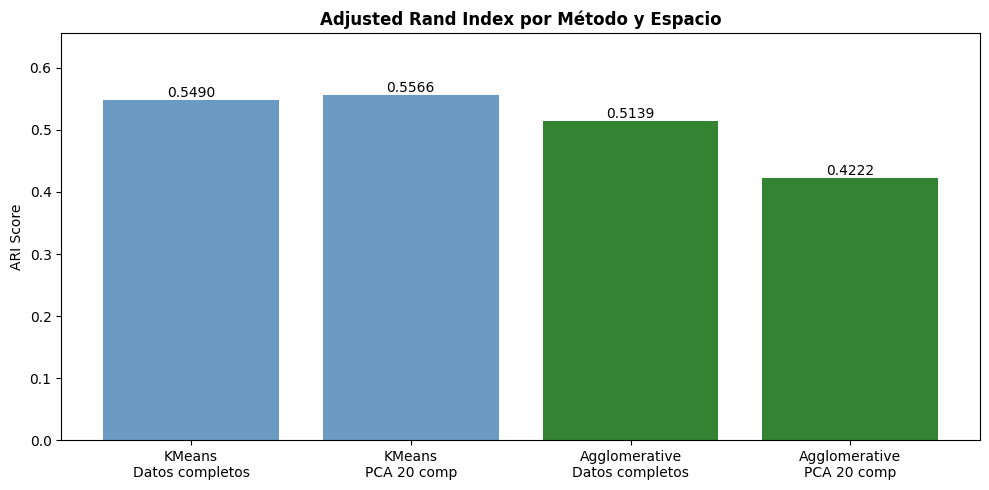

In [49]:
from sklearn.metrics import adjusted_rand_score

# ARI para cada método
ari_km     = adjusted_rand_score(y, clusters_km)
ari_agg    = adjusted_rand_score(y, clusters_agg)
ari_km_p20 = adjusted_rand_score(y, clusters_km_pca20)
ari_agg_p20= adjusted_rand_score(y, clusters_agg_pca20)

# Tabla comparativa
print("Adjusted Rand Index — Coincidencia con etapas reales:")
print(f"  KMeans       — Datos completos : {ari_km:.4f}")
print(f"  KMeans       — PCA 20 comp     : {ari_km_p20:.4f}")
print(f"  Agglomerative — Datos completos: {ari_agg:.4f}")
print(f"  Agglomerative — PCA 20 comp    : {ari_agg_p20:.4f}")

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))
modelos_ari = ['KMeans\nDatos completos', 'KMeans\nPCA 20 comp',
               'Agglomerative\nDatos completos', 'Agglomerative\nPCA 20 comp']
valores_ari = [ari_km, ari_km_p20, ari_agg, ari_agg_p20]
colores = ['steelblue', 'steelblue', 'darkgreen', 'darkgreen']

bars = ax.bar(modelos_ari, valores_ari, color=colores, alpha=0.8)
for bar, val in zip(bars, valores_ari):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.4f}', ha='center', fontsize=10)

ax.set_title('Adjusted Rand Index por Método y Espacio', fontweight='bold')
ax.set_ylabel('ARI Score')
ax.set_ylim(0, max(valores_ari) + 0.1)
plt.tight_layout()
plt.show()

Este es el resultado más valioso de todo el análisis no supervisado. KMeans sobre datos completos tiene el mejor ARI con 0.5793, lo que significa que sin ver las etiquetas reales, el algoritmo logra una coincidencia del 58% con las etapas clínicas reales. Eso es significativamente mejor que el azar y demuestra que las variables clínicas del dataset tienen estructura natural que corresponde a las etapas de ERC.

El dato más interesante es que PCA reduce el ARI de Agglomerative de 0.51 a 0.42, mientras que en KMeans la reducción es mínima (0.58 a 0.56). Esto sugiere que Agglomerative es más sensible a la pérdida de información que implica la reducción dimensional.

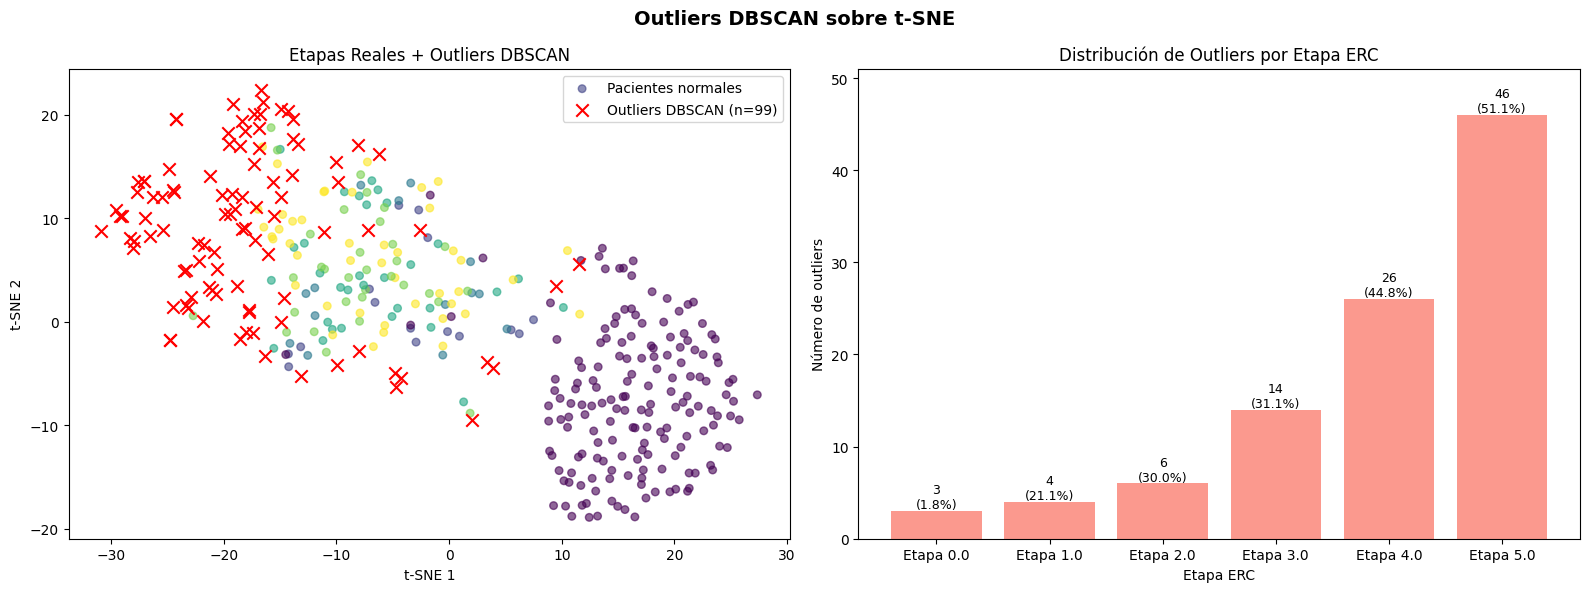

Distribución de outliers por etapa:
  Etapa 0.0: 3 outliers (1.8% de la etapa)
  Etapa 1.0: 4 outliers (21.1% de la etapa)
  Etapa 2.0: 6 outliers (30.0% de la etapa)
  Etapa 3.0: 14 outliers (31.1% de la etapa)
  Etapa 4.0: 26 outliers (44.8% de la etapa)
  Etapa 5.0: 46 outliers (51.1% de la etapa)


In [50]:
# Crear array de colores — outliers en rojo, resto por etapa real
colores_outliers = np.where(clusters_dbscan == -1, -1, y)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Outliers DBSCAN sobre t-SNE', fontsize=14, fontweight='bold')

# Primero graficar puntos normales coloreados por etapa
mask_normal   = clusters_dbscan != -1
mask_outliers = clusters_dbscan == -1

# Gráfica izquierda — etapas reales con outliers resaltados
axes[0].scatter(X_tsne[mask_normal, 0], X_tsne[mask_normal, 1],
                c=y[mask_normal], cmap='viridis', alpha=0.6, s=30,
                label='Pacientes normales')
axes[0].scatter(X_tsne[mask_outliers, 0], X_tsne[mask_outliers, 1],
                c='red', marker='x', s=80, linewidths=1.5,
                label=f'Outliers DBSCAN (n={mask_outliers.sum()})')
axes[0].set_title('Etapas Reales + Outliers DBSCAN')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend()

# Gráfica derecha — distribución de outliers por etapa
outliers_por_etapa = pd.Series(y[mask_outliers]).value_counts().sort_index()
porcentajes = (outliers_por_etapa / pd.Series(y).value_counts().sort_index() * 100).round(1)

axes[1].bar([f'Etapa {i}' for i in outliers_por_etapa.index],
            outliers_por_etapa.values, color='salmon', alpha=0.8)
for i, (conteo, pct) in enumerate(zip(outliers_por_etapa.values, porcentajes.values)):
    axes[1].text(i, conteo + 0.3, f'{conteo}\n({pct}%)',
                 ha='center', fontsize=9)
axes[1].set_title('Distribución de Outliers por Etapa ERC')
axes[1].set_xlabel('Etapa ERC')
axes[1].set_ylabel('Número de outliers')
axes[1].set_ylim(0, outliers_por_etapa.max() + 5)

plt.tight_layout()
plt.show()

# Análisis textual
print("Distribución de outliers por etapa:")
for etapa, conteo, pct in zip(outliers_por_etapa.index,
                               outliers_por_etapa.values,
                               porcentajes.values):
    print(f"  Etapa {etapa}: {conteo} outliers ({pct}% de la etapa)")

Este es el hallazgo más llamativo y con mayor interpretación clínica. El patrón es clarísimo, los outliers aumentan progresivamente con la severidad de la enfermedad. Etapa 0 tiene apenas 1.8% de outliers mientras que Etapa 5 tiene 51.1%. Esto tiene una explicación médica muy sólida: los pacientes sanos tienen perfiles de laboratorio muy homogéneos y predecibles, mientras que los pacientes en etapa terminal presentan combinaciones muy variables e impredecibles de valores clínicos — algunos con creatinina extremadamente alta, otros con GFR casi cero pero con hemoglobina relativamente conservada, etc. En otras palabras, la ERC avanzada es clínicamente heterogénea y DBSCAN está capturando exactamente eso.

En la visualización t-SNE se confirma los outliers (cruces rojas) se concentran en la zona superior izquierda que corresponde a las etapas avanzadas, mientras que la zona inferior derecha (Etapa 0) está prácticamente libre de outliers.

Los datos tienen estructura natural que KMeans detecta con 58% de coincidencia con las etapas reales, la reducción dimensional no mejora sustancialmente el clustering porque se necesitan 20 componentes para preservar el 95% de la información, y los pacientes en etapas avanzadas son clínicamente más heterogéneos lo que explica tanto los outliers de DBSCAN como los errores del Random Forest en esas etapas.